<a href="https://colab.research.google.com/github/KacperLatecki/Zadania_ED/blob/main/zad_miary_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## Zadanie 1
    
Wczytaj dane z pliku **PersonalData.csv**.
    
Oblicz odległość euklidesową \(d(A, B)\) między dwoma wybranymi rekordami \(A\) i \(B\).
    
Zmodyfikuj skalę dla atrybutu **zarobki** (przeskaluj jednostki z tysięcy na złote) i ponownie oblicz odległość euklidesową. Jak zmiana skali wpływa na wynik?
    
Aby wyeliminować wpływ skali, podziel wartość każdego atrybutu przez jego odchylenie standardowe. Oblicz ponownie odległość euklidesową dla przeskalowanych danych.
    
Dla punktów \(A\) i \(B\) oblicz także odległość Minkowskiego oraz odległość miejską (Manhattan).

In [2]:
import pandas as pd
import numpy as np

# =========================
# ZADANIE 1 – MIARY ODLEGŁOŚCI
# =========================

# 1) Wczytanie danych
df = pd.read_csv("PersonalData.csv")

# 2) Wybór rekordów A i B
A = df.iloc[0]
B = df.iloc[1]

# Kolumny liczbowe
num_cols = df.select_dtypes(include=[np.number]).columns

xA = A[num_cols].to_numpy(dtype=float)
xB = B[num_cols].to_numpy(dtype=float)

print("Cechy liczbowe:", list(num_cols))
print("\nRekord A:\n", xA)
print("\nRekord B:\n", xB)

# 3) Odległość euklidesowa
d_euclid = np.linalg.norm(xA - xB)
print("\nOdległość euklidesowa:", d_euclid)

# 4) Zmiana skali atrybutu 'Zarobki (tys.)' (tys. -> zł)
df_scaled = df.copy()
df_scaled["Zarobki (tys.)"] = df_scaled["Zarobki (tys.)"] * 1000

A2 = df_scaled.iloc[0]
B2 = df_scaled.iloc[1]

xA2 = A2[num_cols].to_numpy(dtype=float)
xB2 = B2[num_cols].to_numpy(dtype=float)

d_euclid_scaled_salary = np.linalg.norm(xA2 - xB2)
print("\nOdległość euklidesowa po przeskalowaniu zarobków:", d_euclid_scaled_salary)

# 5) Normalizacja przez rozstęp (eliminacja wpływu skali)
X = df[num_cols].astype(float)
ranges = X.max() - X.min()
ranges_safe = ranges.replace(0, 1.0)

X_norm = X / ranges_safe

xA_norm = X_norm.iloc[0].to_numpy()
xB_norm = X_norm.iloc[1].to_numpy()

d_euclid_norm = np.linalg.norm(xA_norm - xB_norm)
print("\nOdległość euklidesowa po normalizacji:", d_euclid_norm)

# 6) Odległość Manhattan i Minkowskiego (p=3)
d_manhattan = np.sum(np.abs(xA - xB))
d_minkowski_p3 = np.sum(np.abs(xA - xB)**3)**(1/3)

print("\nOdległość Manhattan:", d_manhattan)
print("Odległość Minkowskiego (p=3):", d_minkowski_p3)

# 7) Porównanie różnicy zarobków (pokazanie dominacji skali)
salary_diff_thousands = abs(df.loc[0, "Zarobki (tys.)"] - df.loc[1, "Zarobki (tys.)"])
salary_diff_scaled = abs(df_scaled.loc[0, "Zarobki (tys.)"] - df_scaled.loc[1, "Zarobki (tys.)"])

print("\nRóżnica zarobków (tys.):", salary_diff_thousands)
print("Różnica zarobków po skali (zł):", salary_diff_scaled)


Cechy liczbowe: ['Wzrost (cm)', 'Waga (kg)', 'Staz (lata)', 'Zarobki (tys.)', 'Ocena (pkt.)', 'Piętro', 'Dzieci', 'Odleglosc (km)']

Rekord A:
 [190.   88.    3.    3.5   7.    6.    1.   25. ]

Rekord B:
 [172.   70.   12.    4.3   5.    1.    4.   12. ]

Odległość euklidesowa: 30.604574821421714

Odległość euklidesowa po przeskalowaniu zarobków: 800.5847862656397

Odległość euklidesowa po normalizacji: 2.8284271247461903

Odległość Manhattan: 68.8
Odległość Minkowskiego (p=3): 24.524624416199366

Różnica zarobków (tys.): 0.7999999999999998
Różnica zarobków po skali (zł): 800.0


## Zadanie 2

Masz opisy trzech filmów
- `film1 = "kosmiczna stacja astronauta planeta obca"`
- `film2 = "astronauta rakieta księżyc misja kosmiczna"`
- `film3 = "wampir zamek noc krew mroczny"`

a. Stwórz reprezentację wektorową dla każdego filmu używając CountVectorizer

b. Oblicz podobieństwo cosinusowe między wszystkimi parami filmów

c. Które dwa filmy są najbardziej podobne? Które najmniej?

d . Dodaj czwarty film i sprawdź do którego jest najbardziej podobny:
    `film4 = "rakieta mars astronauta czerwona planeta"`

In [3]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# ZADANIE 2 – COUNT VECTORIZER + COSINE SIMILARITY
# =========================

film1 = "kosmiczna stacja astronauta planeta obca"
film2 = "astronauta rakieta księżyc misja kosmiczna"
film3 = "wampir zamek noc krew mroczny"

docs = [film1, film2, film3]
labels = ["film1", "film2", "film3"]

# a) Reprezentacja wektorowa (CountVectorizer)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

vocab = vectorizer.get_feature_names_out()
X_df = pd.DataFrame(X.toarray(), index=labels, columns=vocab)

print("Słownik (cechy):", list(vocab))
print("\nMacierz zliczeń (CountVectorizer):")
display(X_df)

# b) Podobieństwo cosinusowe dla wszystkich par
S = cosine_similarity(X)  # 3x3
S_df = pd.DataFrame(S, index=labels, columns=labels)

print("\nMacierz podobieństwa cosinusowego:")
display(S_df)

# c) Najbardziej podobne i najmniej podobne (spośród par)
pairs = []
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        pairs.append((labels[i], labels[j], S[i, j]))

pairs_sorted = sorted(pairs, key=lambda t: t[2], reverse=True)

most_similar = pairs_sorted[0]
least_similar = pairs_sorted[-1]

print(f"\nNajbardziej podobne: {most_similar[0]} i {most_similar[1]} (cos={most_similar[2]:.3f})")
print(f"Najmniej podobne:   {least_similar[0]} i {least_similar[1]} (cos={least_similar[2]:.3f})")

# d) Dodanie film4 i sprawdzenie podobieństwa
film4 = "rakieta mars astronauta czerwona planeta"
docs2 = [film1, film2, film3, film4]
labels2 = ["film1", "film2", "film3", "film4"]

X2 = vectorizer.fit_transform(docs2)  # uczymy słownik na wszystkich 4 opisach
vocab2 = vectorizer.get_feature_names_out()
X2_df = pd.DataFrame(X2.toarray(), index=labels2, columns=vocab2)

print("\nMacierz zliczeń po dodaniu film4:")
display(X2_df)

S2 = cosine_similarity(X2)
S2_df = pd.DataFrame(S2, index=labels2, columns=labels2)

print("\nMacierz podobieństwa cosinusowego po dodaniu film4:")
display(S2_df)

sim_to_4 = S2_df.loc["film4"].drop("film4").sort_values(ascending=False)
print("\nPodobieństwo film4 do pozostałych:")
display(sim_to_4.to_frame("cosine_similarity"))

print(f"Film4 jest najbardziej podobny do: {sim_to_4.index[0]} (cos={sim_to_4.iloc[0]:.3f})")


Słownik (cechy): ['astronauta', 'kosmiczna', 'krew', 'księżyc', 'misja', 'mroczny', 'noc', 'obca', 'planeta', 'rakieta', 'stacja', 'wampir', 'zamek']

Macierz zliczeń (CountVectorizer):


,astronauta,kosmiczna,krew,księżyc,misja,mroczny,noc,obca,planeta,rakieta,stacja,wampir,zamek
film1,1,1,0,0,0,0,0,1,1,0,1,0,0
film2,1,1,0,1,1,0,0,0,0,1,0,0,0
film3,0,0,1,0,0,1,1,0,0,0,0,1,1



Macierz podobieństwa cosinusowego:


,film1,film2,film3
film1,1.0,0.4,0.0
film2,0.4,1.0,0.0
film3,0.0,0.0,1.0



Najbardziej podobne: film1 i film2 (cos=0.400)
Najmniej podobne:   film2 i film3 (cos=0.000)

Macierz zliczeń po dodaniu film4:


...


Macierz podobieństwa cosinusowego po dodaniu film4:


,film1,film2,film3,film4
film1,1.0,0.4,0.0,0.4
film2,0.4,1.0,0.0,0.4
film3,0.0,0.0,1.0,0.0
film4,0.4,0.4,0.0,1.0



Podobieństwo film4 do pozostałych:


,cosine_similarity
film1,0.4
film2,0.4
film3,0.0


Film4 jest najbardziej podobny do: film1 (cos=0.400)


## Zadanie 3

1. Załaduj zbiór danych **iris**.
Opis zbioru: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html
2. Narysuj wykres rozrzutu dla współrzędnych **sepal_length** i **sepal_width**. Oznacz różnymi
kolorami i marklami różne klasy kwiatów.
3. Znajdź wartości **minimalne, maksymalne** oraz **średnie odchylenie kwadratowe** dla atrybutów zbioru.
4. Policz **współczynniki korelacji** między atrybutami.
5. Zastosuj **algorytm k-średnich** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.
6. Zastosuj **algorytm hierarchiczny aglomeracyjny** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.

,sepal_length,sepal_width,petal_length,petal_width,target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


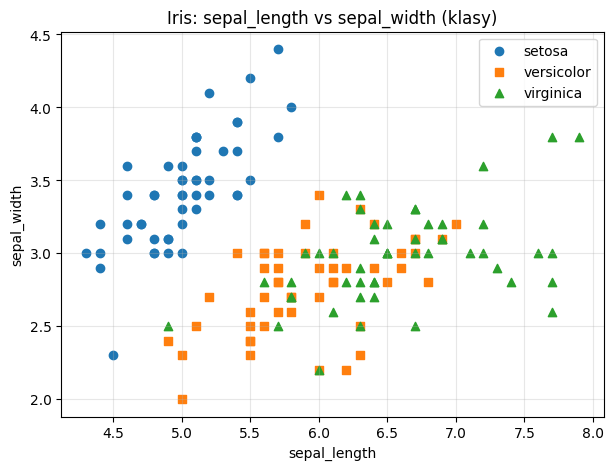

Statystyki opisowe (min, max, odchylenie standardowe):


,min,max,std (odchylenie)
sepal_length,4.3,7.9,0.825301
sepal_width,2.0,4.4,0.434411
petal_length,1.0,6.9,1.759404
petal_width,0.1,2.5,0.759693


Macierz korelacji:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


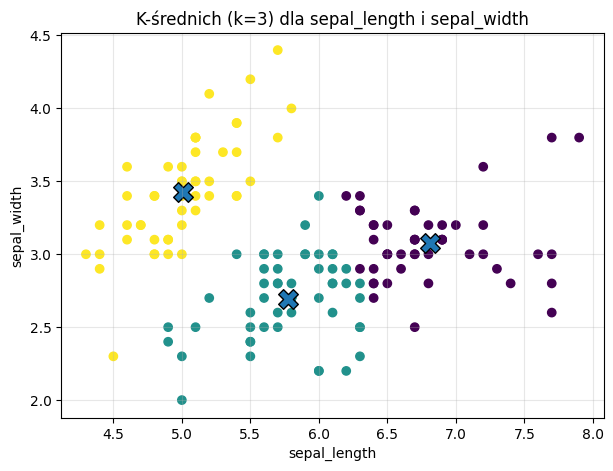

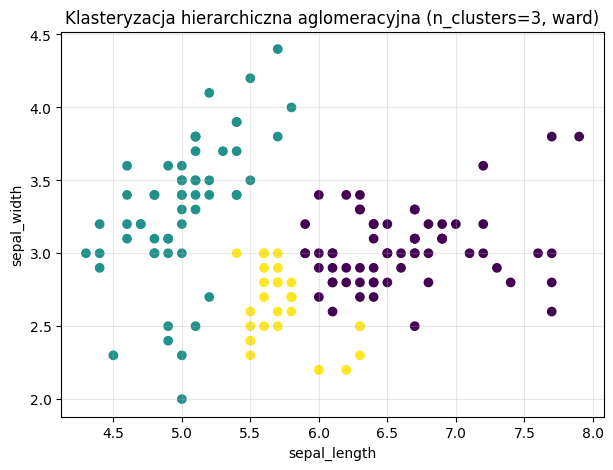

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering

# =========================
# ZADANIE 3 – IRIS
# =========================

# 1) Załaduj zbiór danych iris
iris = datasets.load_iris(as_frame=True)
df = iris.frame.copy()  # zawiera cechy + target
df["class"] = df["target"].map({i: name for i, name in enumerate(iris.target_names)})

# Ujednolicenie nazw jak w poleceniu (sepal_length, sepal_width)
df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})

display(df.head())

# 2) Wykres rozrzutu sepal_length vs sepal_width z klasami (różne kolory i markery)
markers = {"setosa": "o", "versicolor": "s", "virginica": "^"}

plt.figure(figsize=(7, 5))
for cls in df["class"].unique():
    d = df[df["class"] == cls]
    plt.scatter(d["sepal_length"], d["sepal_width"], marker=markers[cls], label=cls)
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("Iris: sepal_length vs sepal_width (klasy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3) Minimalne, maksymalne i średnie odchylenie kwadratowe (tu: odchylenie standardowe)
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

stats = pd.DataFrame({
    "min": df[feature_cols].min(),
    "max": df[feature_cols].max(),
    "std (odchylenie)": df[feature_cols].std(ddof=0)  # populacyjne; jeśli chcesz próbkę: ddof=1
})
print("Statystyki opisowe (min, max, odchylenie standardowe):")
display(stats)

# 4) Współczynniki korelacji między atrybutami
corr = df[feature_cols].corr()
print("Macierz korelacji:")
display(corr)

# 5) K-średnich dla współrzędnych sepal_length i sepal_width
X = df[["sepal_length", "sepal_width"]].to_numpy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(df["sepal_length"], df["sepal_width"], c=km_labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=200, edgecolor="k")
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("K-średnich (k=3) dla sepal_length i sepal_width")
plt.grid(True, alpha=0.3)
plt.show()

# 6) Hierarchiczny aglomeracyjny (podział na klastry) dla sepal_length i sepal_width
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")  # ward działa dla metryki euklidesowej
agg_labels = agg.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(df["sepal_length"], df["sepal_width"], c=agg_labels)
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("Klasteryzacja hierarchiczna aglomeracyjna (n_clusters=3, ward)")
plt.grid(True, alpha=0.3)
plt.show()


## Zadanie 4
Dla danych z pliku penguins.csv wykonaj polecenia

Wyświetl podstawowe informacje o zbiorze.
1. Sprawdź czy w zbiorze nie brakuje danych. Jeżeli są – usuń je ().
2. Ogranicz się do atrybutów **bill_length_mm** i **flipper_length_mm**.
3. Narysuj dendogram, zinterpretuj go i wyznacz ilość klastrów.
4. Zastosuj algorytm hierarchiczny aglomeracyjny do zbioru i wyznacz klastry.
5. Stwórz wykres rozrzutu z zaznaczonymi klastrami.

W **punktach 3-5** przetestuj różne sposoby obliczenia odległości między klastrami (linkage-complete, average, single, ward).

Dane z https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv

In [ ]:
df = pd.read_csv("PersonalData.csv", index_col=0, delimiter=",")

In [ ]:
df

,Wzrost (cm),Waga (kg),Staz (lata),Zarobki (tys.),Ocena (pkt.),Piętro,Dzieci,Odleglosc (km),Ubezp.
A,190,88,3,3.5,7,6,1,25,Tak
B,172,70,12,4.3,5,1,4,12,Nie


In [ ]:
df.loc['A']

,A
Wzrost (cm),190
Waga (kg),88
Staz (lata),3
Zarobki (tys.),3.5
Ocena (pkt.),7
Piętro,6
Dzieci,1
Odleglosc (km),25
Ubezp.,Tak


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Liczba wierszy przed: 344 po usunięciu braków: 342


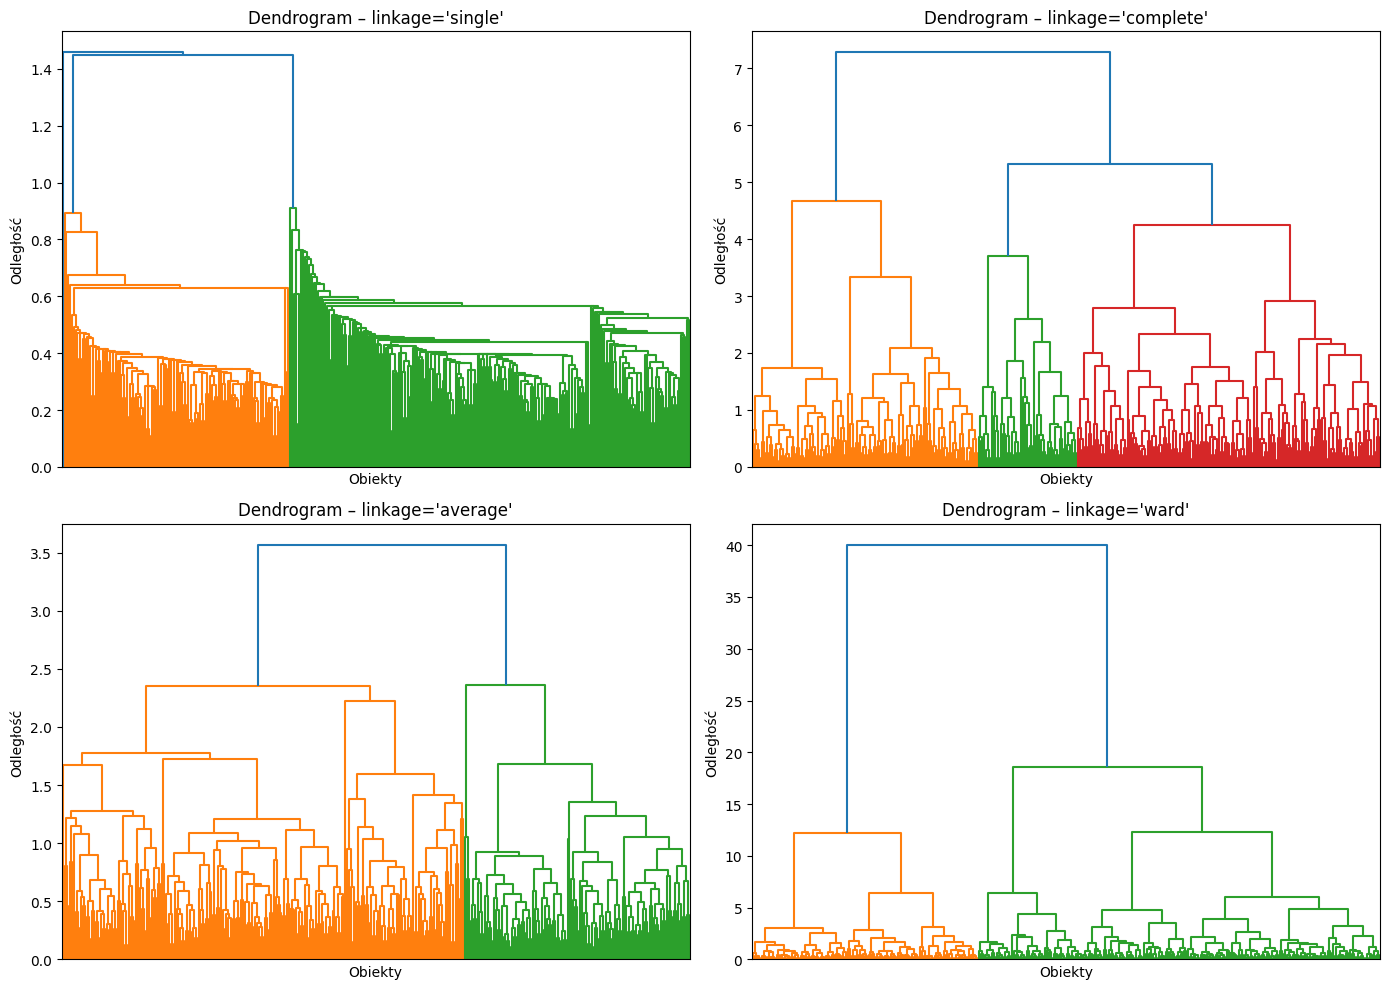

Silhouette (im wyżej, tym lepiej):


,single,complete,average,ward
2,0.252746,0.531540,0.531540,0.531540
3,0.469475,0.451554,0.441617,0.454095
4,0.315037,0.394167,0.385856,0.417595
5,0.261469,0.348668,0.368137,0.363161
6,0.139948,0.326615,0.345795,0.334631
7,0.023704,0.304796,0.310526,0.305395


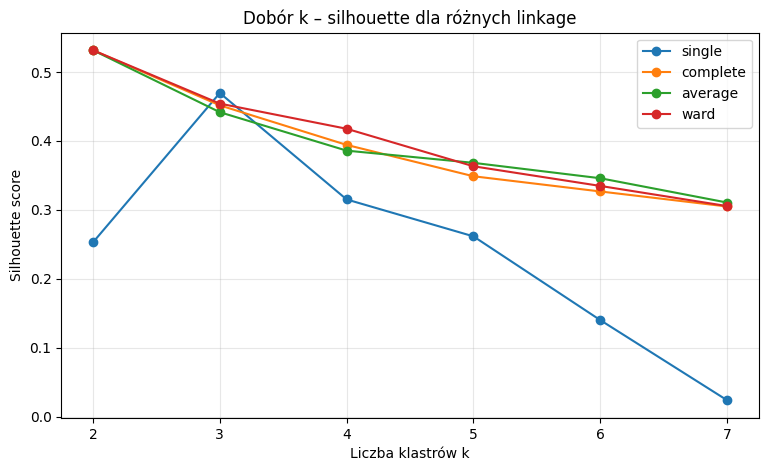

Najlepszy wynik silhouette: 0.5315 dla linkage='complete', k=2


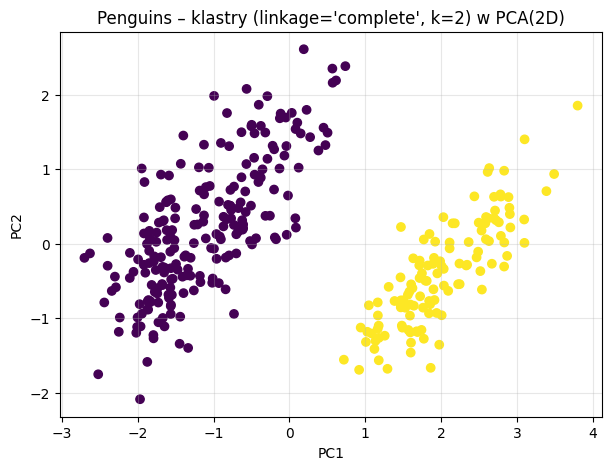

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

# =========================
# ZADANIE 4 – PENGUINS (KLASTERYZACJA HIERARCHICZNA)
# =========================

# 1) Wczytanie danych
peng = pd.read_csv("penguins.csv")
display(peng.head())

# 2) Wybór cech liczbowych (typowo używane w penguins)
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_raw = peng[features].copy()

# Usuwamy wiersze z brakami (żeby metody działały)
mask = X_raw.notna().all(axis=1)
peng_clean = peng.loc[mask].copy()
X_raw = X_raw.loc[mask].copy()

print("Liczba wierszy przed:", len(peng), "po usunięciu braków:", len(peng_clean))

# 3) Standaryzacja (ważne, bo skale są różne)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 4) Dendrogramy dla różnych metod łączenia (linkage)
linkages = {
    "single": "single",
    "complete": "complete",
    "average": "average",
    "ward": "ward"  # ward działa sensownie dla euklidesowej + danych ciągłych
}

plt.figure(figsize=(14, 10))
for i, (name, method) in enumerate(linkages.items(), start=1):
    Z = linkage(X, method=method)
    plt.subplot(2, 2, i)
    dendrogram(Z, no_labels=True, color_threshold=None)
    plt.title(f"Dendrogram – linkage='{name}'")
    plt.xlabel("Obiekty")
    plt.ylabel("Odległość")
plt.tight_layout()
plt.show()

# 5) Dobór liczby klastrów (silhouette) dla każdej metody (poza ward: wszystkie OK, ward też OK)
# Uwaga: silhouette działa sensownie dla k>=2
k_range = range(2, 8)
scores = {}

for name, method in linkages.items():
    scores[name] = []
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X)
        s = silhouette_score(X, labels)
        scores[name].append(s)

scores_df = pd.DataFrame(scores, index=list(k_range))
print("Silhouette (im wyżej, tym lepiej):")
display(scores_df)

# Wykres silhouette
plt.figure(figsize=(9, 5))
for name in linkages.keys():
    plt.plot(list(k_range), scores[name], marker="o", label=name)
plt.xlabel("Liczba klastrów k")
plt.ylabel("Silhouette score")
plt.title("Dobór k – silhouette dla różnych linkage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 6) Wybór najlepszego (metoda, k) wg silhouette
best_method = None
best_k = None
best_score = -1

for name in linkages.keys():
    vals = scores[name]
    k_best_for_method = list(k_range)[int(np.argmax(vals))]
    score_best_for_method = float(np.max(vals))
    if score_best_for_method > best_score:
        best_score = score_best_for_method
        best_method = name
        best_k = k_best_for_method

print(f"Najlepszy wynik silhouette: {best_score:.4f} dla linkage='{best_method}', k={best_k}")

# 7) Finalna klasteryzacja najlepszym wariantem + wizualizacja w 2D (PCA)
final_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_method)
final_labels = final_model.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=final_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Penguins – klastry (linkage='{best_method}', k={best_k}) w PCA(2D)")
plt.grid(True, alpha=0.3)
plt.show()
